### Single Node -  Run time validation

In [1]:
from typing_extensions import TypedDict

class State(TypedDict):
    xyz:str
    abc:str

In [2]:
from langgraph.graph import StateGraph,START,END
from pydantic import BaseModel

class OverallState(BaseModel):
    a:str

def node(state:OverallState):
    return {"a": "Hii, I am sai krishna"}

In [3]:
# Build the State Graph

builder = StateGraph(OverallState)
builder.add_node("node",node)
builder.add_edge(START,"node")
builder.add_edge("node",END)
graph = builder.compile()



In [4]:
graph.invoke({"a":"hello"})

{'a': 'Hii, I am sai krishna'}

### Multiple Nodes - Run time validation

In [7]:
from langgraph.graph import StateGraph,START,END
from typing_extensions import TypedDict
from pydantic import BaseModel

class OverallState(BaseModel):
    a: str 

def bad_node(state:OverallState):
    return {
        "a": "Hii, This is sai krishna" # Invalid
    }

def ok_node(state:OverallState):
    return {
        "a": "good bye"
    }

builder = StateGraph(OverallState)
builder.add_node("bad_node",bad_node)
builder.add_node("ok_node",ok_node)
builder.add_edge(START,"bad_node")
builder.add_edge("bad_node","ok_node")
builder.add_edge("ok_node",END)

graph = builder.compile()

graph.invoke({"a":"Hello"})

{'a': 'good bye'}

### Prompt Chaining

Prompt chaining decomposes a task into a sequence of steps, where each LLM call processes the output of the previous one. You can add programmatic checks on any intermediate steps to ensure that the process is still on track.

When to use this workflow: This workflow is ideal for situations where the task can be easily and cleanly decomposed into fixed subtasks. The main goal is to trade off latency for higher accuracy, by making each LLM call an easier task.

![promptchaining](images/prompt-chaining.png)

In [9]:
import os 
from dotenv import load_dotenv
load_dotenv()

from langchain_groq import ChatGroq

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

llm = ChatGroq(model="qwen-2.5-32b")
result = llm.invoke("hello")
result

AIMessage(content='Hello! How can I assist you today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 30, 'total_tokens': 40, 'completion_time': 0.05, 'prompt_time': 0.003702295, 'queue_time': 0.236243444, 'total_time': 0.053702295}, 'model_name': 'qwen-2.5-32b', 'system_fingerprint': 'fp_35f92f8282', 'finish_reason': 'stop', 'logprobs': None}, id='run-4bdcfa2f-cd82-4965-9dc1-72fd037000a1-0', usage_metadata={'input_tokens': 30, 'output_tokens': 10, 'total_tokens': 40})

In [10]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph,START,END
from IPython.display import Image,display

class State(TypedDict):
    topic:str
    joke:str
    improved_joke:str
    final_joke:str 
    

In [11]:
# Nodes

def generate_joke(state:State):
    """ First LLM call to generate the initial joke"""

    msg = llm.invoke(f"Write a short joke about {state['topic']}")
    return {"joke":msg.content}

def check_punchline(state:State):
    """ Gate function to check if the joke has a punchline"""

    if "?" in state["joke"] or "!" in state["joke"]:
        return "Fail"
    
    return "Pass"

def improve_joke(state:State):
    """ Second LLM call to improve the joke"""
    msg = llm.invoke(f"Make this joke funnier by adding wordplay: {state['joke']}")
    return {"improved_joke":msg.content}

def polish_joke(state:State):
    """ Third LLM call for final polish"""
    msg = llm.invoke(f"Add a surprising twist to the joke: {state['improved_joke']}")
    return {"final_joke":msg.content}

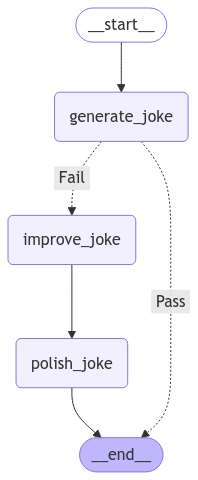

In [12]:
# Build workflow

workflow = StateGraph(State)

#Add nodes
workflow.add_node("generate_joke",generate_joke)
workflow.add_node("improve_joke",improve_joke)
workflow.add_node("polish_joke",polish_joke)

# Add Edges
workflow.add_edge(START,"generate_joke")
workflow.add_conditional_edges("generate_joke",check_punchline,{"Fail":"improve_joke","Pass":END})
workflow.add_edge("improve_joke","polish_joke")
workflow.add_edge("polish_joke",END)

chain = workflow.compile()

display(Image(chain.get_graph().draw_mermaid_png()))



In [16]:
chain.invoke({"topic":"Michal jackson"})

{'topic': 'Michal jackson',
 'joke': 'Why did Michael Jackson refuse to join the dance-off?\n\nBecause he already moonwalked the talk!',
 'improved_joke': 'Why did Michael Jackson refuse to join the dance-off?\n\nBecause he already moonwalked the walk and talked the talk so much, he wanted to let someone else do the talk and the walk for a change!',
 'final_joke': 'Because he already moonwalked the walk and talked the talk so much, he wanted to let someone else do the talk and the walk for a change! But everyone was shocked when he refused to join because, unbeknownst to them, he was secretly training an alien army to perfect the moonwalk in a distant galaxy!'}

### Parallelaization

With parallelization, LLMs work simultaneously on a task:

LLMs can sometimes work simultaneously on a task and have their outputs aggregated programmatically. This workflow, parallelization, manifests in two key variations: Sectioning: Breaking a task into independent subtasks run in parallel. Voting: Running the same task multiple times to get diverse outputs.

When to use this workflow: Parallelization is effective when the divided subtasks can be parallelized for speed, or when multiple perspectives or attempts are needed for higher confidence results. For complex tasks with multiple considerations, LLMs generally perform better when each consideration is handled by a separate LLM call, allowing focused attention on each specific aspect.

![parallelization](images/Parallelization.png)

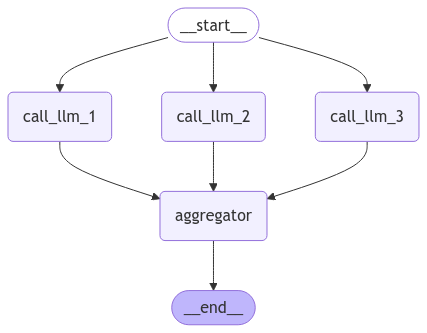

Here is a joke,story and poem about the cats

STORY:
 In the heart of a bustling city, where skyscrapers kissed the cloud-strewn skies and the hustle of daily life was a constant hum, there was a quiet alleyway that was far removed from the chaos. This alleyway was home to a community of cats, each with their own quirks and stories, but all bound by an unspoken bond that made them more than just a group of stray animals. They were a family.

At the center of this feline community was Whiskers, a sleek black cat with piercing green eyes that could see right through the heart of any challenge. He was the leader, respected for his wisdom and bravery. Whiskers had a knack for finding the best spots for a nap—be it atop a dumpster, under a warm patch of sun filtering through the alley's narrow confines, or curled up in an old shoe that had seen better days but still provided a cozy nook.

Living alongside Whiskers was a charming calico cat named Lilac. With her fur in a patchwork of orange,

In [18]:
class State(TypedDict):
    topic:str
    joke:str
    story:str
    poem:str 
    combined_output:str

def call_llm_1(state:State):
    """First LLM call to generate initial joke"""
    msg = llm.invoke(f"Write a joke about {state['topic']}")
    return {"joke":msg.content}

def call_llm_2(state:State):
    """Second LLM call to generate Story"""
    msg = llm.invoke(f"Write a story about {state['topic']}")
    return {"story":msg.content}

def call_llm_3(state:State):
    """Third LLM call to generate poem"""
    msg = llm.invoke(f"Write a poem about {state['topic']}")
    return {"poem":msg.content}

def aggregator(state:State):
    """combine the story,poem,joke into a single output"""
    
    combined = f"Here is a joke,story and poem about the {state['topic']}\n\n"
    combined += f"STORY:\n {state['story']}\n\n"
    combined += f"JOKE: \n {state['joke']}\n\n"
    combined += f"POEM: \n {state['poem']}\n "

    return {"combined_output": combined}


# Build Workflow
parallel_builder = StateGraph(State)

# Add Nodes
parallel_builder.add_node("call_llm_1",call_llm_1)
parallel_builder.add_node("call_llm_2",call_llm_2)
parallel_builder.add_node("call_llm_3",call_llm_3)
parallel_builder.add_node("aggregator",aggregator)

# Add Edges to connect nodes
parallel_builder.add_edge(START,"call_llm_1")
parallel_builder.add_edge(START,"call_llm_2")
parallel_builder.add_edge(START,"call_llm_3")
parallel_builder.add_edge("call_llm_1","aggregator")
parallel_builder.add_edge("call_llm_2","aggregator")
parallel_builder.add_edge("call_llm_3","aggregator")
parallel_builder.add_edge("aggregator",END)

parallel_workflow = parallel_builder.compile()

# show workflow
display(Image(parallel_workflow.get_graph().draw_mermaid_png()))

# Invoke
state_output = parallel_workflow.invoke({"topic":"cats"})
print(state_output["combined_output"])

### Routing

Routing classifies an input and directs it to a specialized followup task. This workflow allows for separation of concerns, and building more specialized prompts. Without this workflow, optimizing for one kind of input can hurt performance on other inputs.

When to use this workflow: Routing works well for complex tasks where there are distinct categories that are better handled separately, and where classification can be handled accurately, either by an LLM or a more traditional classification model/algorithm.

![routing](images/Router.png)

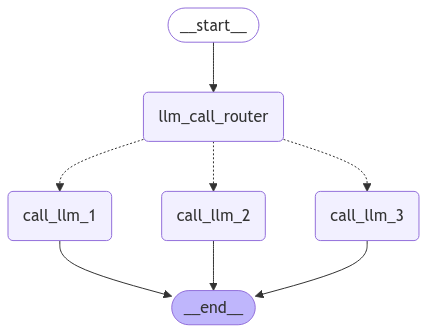

Why don't cats make good dancers?

Because they have two left feet!


In [22]:
from typing_extensions import Literal
from langchain_core.pydantic_v1 import Field,BaseModel
from langchain_core.messages import SystemMessage,HumanMessage

# schema for structured output to use a routing logic
class Route(BaseModel):
    step: Literal["story","poem","joke"] = Field(
        None, description="The next step in the routing process"
    )

# Augment the LLM with schema for structured output
router = llm.with_structured_output(Route)

#State
class State(TypedDict):
    input:str
    decision:str
    output:str 

# Nodes
def call_llm_1(state:State):
    """Write a story"""
    result = llm.invoke(state["input"])
    return {"output": result.content}

def call_llm_2(state:State):
    """Write a joke"""
    result = llm.invoke(state["input"])
    return {"output": result.content}

def call_llm_3(state:State):
    """Write a poem"""
    result = llm.invoke(state["input"])
    return {"output": result.content}


def llm_call_router(state:State):
    """Route the input to appropriate node"""

    # Run the augmented LLM with structured output to serve as routing logic

    decision = router.invoke(
        [
            SystemMessage(content = "Route the input to story,joke or poem based on user's request"),
            HumanMessage(content= state["input"])
        ]
    )

    return {"decision":decision.step}

# conditional edge function to route to the appropriate node

def route_decision(state:State):
    # Return the node name which you want to visit next.
    if state["decision"] == "story":
        return "call_llm_1"
    elif state["decision"] == "poem":
        return "call_llm_3"
    elif state["decision"] == "joke":
        return "call_llm_2"

# Build workflow  
route_builder = StateGraph(State)

# Add nodes
route_builder.add_node("call_llm_1",call_llm_1)
route_builder.add_node("call_llm_2",call_llm_2)
route_builder.add_node("call_llm_3",call_llm_3)
route_builder.add_node("llm_call_router",llm_call_router)

# Add edges
route_builder.add_edge(START,"llm_call_router")
route_builder.add_conditional_edges(
    "llm_call_router",
    route_decision,
    {
        "call_llm_1":"call_llm_1",
        "call_llm_2":"call_llm_2",
        "call_llm_3":"call_llm_3"
    }
)
route_builder.add_edge("call_llm_1",END)
route_builder.add_edge("call_llm_2",END)
route_builder.add_edge("call_llm_3",END)

route_workflow = route_builder.compile()

display(Image(route_workflow.get_graph().draw_mermaid_png()))

#Invoke
state = route_workflow.invoke({"input":"write me a joke about cats"})
print(state["output"])

### Orchestrator-Worker

In the orchestrator-workers workflow, a central LLM dynamically breaks down tasks, delegates them to worker LLMs, and synthesizes their results.

When to use this workflow: This workflow is well-suited for complex tasks where you can’t predict the subtasks needed (in coding, for example, the number of files that need to be changed and the nature of the change in each file likely depend on the task). Whereas it’s topographically similar, the key difference from parallelization is its flexibility—subtasks aren't pre-defined, but determined by the orchestrator based on the specific input.

![orchestrator](images/Orchestrator.png)

In [23]:
from typing import Annotated,List
import operator 

class Section(BaseModel):
    name: str = Field(
        description = "Name for the section of the report"
    )
    description: str = Field(
        descripton = "Brief overview of the main topics and concepts to be covered in this section"
    )

class Sections(BaseModel):
    sections: List[Section] = Field(
        description="sections of the report"
    )

planner = llm.with_structured_output(Sections)



### Creating Workers using LangGraph

In [24]:
from langgraph.constants import Send

# Graph State
class State(TypedDict):
    topic:str # Report topic
    sections: List[Section] # List of report sections
    completed_sections : Annotated[list,operator.add] # All workers write to this key in parallel
    final_report: str # Final report

# Worker State
class WorkerState(TypedDict):
    section : Section
    completed_sections : Annotated[list,operator.add]

# Nodes
def Orchestrator(state:State):
    """Orchestrator that generates the plan for report"""
    # Generate queries
    report_sections = planner.invoke(
        [
            SystemMessage(content="Generate a plan for the report"),
            HumanMessage(content = f"Here is the report topic {state["topic"]}")
        ]
    )
    return {"sections":report_sections.sections}

def llm_call(state:WorkerState):
    """Worker writes a section of the report"""

    section = llm.invoke(
        [
            SystemMessage(content="Write the report section following the provided name and description.Include no preamble for each section.use markdown formatting."),
            HumanMessage(content = f"Here is the section name {state['section'].name} and descripton {state['section'].description}")
        ]
    )

    return {"completed_sections": [section.content]}

def synthesizer(state:State):
    """synthesize full report from the sections"""
    completed_sections = state["completed_sections"]

    completed_report_sections = "\n\n-----\n\n".join(completed_sections)
    return {"final_report": completed_report_sections}


def assign_workers(state:State):
    """Assign a worker to each section in the plan"""

    # kick off section writing in parallel via send() API
    return [Send("llm_call",{"section":s}) for s in state["sections"]]

c:\One-Drive\OneDrive - Tredence\Agentic-AI\agent-venv\Lib\site-packages\pydantic\_internal\_generate_schema.py:775: UserWarning: Mixing V1 models and V2 models (or constructs, like `TypeAdapter`) is not supported. Please upgrade `Section` to V2.
  warn(


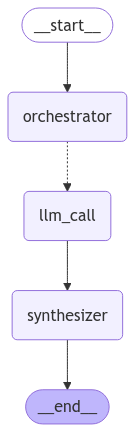

# Introduction to Agentic AI RAGs

Agentic AI RAGs, or Retrieval-Augmented Generation models with agency, are advanced AI systems designed to not only retrieve and generate text based on available data but also to act with a certain degree of autonomy and purpose. These models are significant in the field of artificial intelligence because they blend the capabilities of retrieval-based models, which excel at accessing and utilizing external knowledge, with generative models that can produce coherent and contextually relevant outputs. The addition of "agency" implies that these systems can make decisions and take actions toward achieving goals, which makes them particularly powerful for complex tasks such as customer service, content creation, and decision support systems. Agentic AI RAGs represent a step forward in making AI systems more adaptable, interactive, and effective in real-world applications, thereby opening up new possibilities for human-AI interaction and collaboration.

-----

## Overview of Agentic AI RAGs

Agentic AI RAGs (Retrieval-Augmented Generation) are advanced AI systems designed to leverage both retrieval and generation models to provide contextually rich and accurate responses. Core concepts of Agentic AI RAGs include the integration of external knowledge bases, context-aware decision-making, and the ability to generate human-like text based on accessed information.

### Core Concepts
1. **Retrieval Mechanism**: Agentic AI RAGs use sophisticated algorithms to search and retrieve relevant information from vast knowledge bases, ensuring that the context of the query is understood and appropriately addressed.
2. **Generation Model**: Coupled with the retrieval system, the generation model synthesizes the retrieved information to produce coherent and contextually relevant responses.
3. **Knowledge Integration**: These systems are capable of integrating external knowledge to enhance the accuracy and depth of their responses, making them highly adaptable to various domains such as healthcare, finance, and education.

### Features
- **Contextual Understanding**: Agentic AI RAGs excel at understanding the nuances of user queries and providing responses that are not only accurate but also contextually appropriate.
- **Dynamic Adaptability**: They can adapt to new data and update their knowledge bases in real-time, ensuring that they remain current and effective.
- **Multi-Modal Capabilities**: Beyond text, Agentic AI RAGs can process and generate responses based on images, audio, and other data types, enhancing their utility in complex applications.

### Capabilities
- **Complex Query Handling**: These systems can handle complex and multi-faceted queries, pulling together information from various sources to provide comprehensive answers.
- **Personalization**: Agentic AI RAGs can be tailored to individual user preferences, learning from interaction history to deliver more personalized and relevant responses.
- **Scalability**: Designed for scalability, Agentic AI RAGs can be deployed across a range of applications, from customer service chatbots to personalized learning assistants.

Agentic AI RAGs represent an evolution in AI, blending the strengths of retrieval and generation models to create a powerful tool for information processing and communication.

-----

### Applications of Agentic AI RAGs

Agentic AI RAGs (Retrieval-Augmented Generation) have found diverse applications across various industries due to their ability to combine the strengths of retrieval-based and generative models. Here are some notable use cases:

- **Healthcare:**
  - **Medical Diagnostics:** Agentic AI RAGs can assist in medical diagnostics by analyzing patient data, retrieving relevant medical literature, and generating personalized treatment plans.
  - **Patient Interaction:** AI-powered chatbots can provide patient support, answer queries, and monitor patient symptoms, improving healthcare accessibility and patient engagement.

- **Finance:**
  - **Risk Management:** In risk assessment and management, AI RAGs can retrieve and analyze historical data to predict and mitigate financial risks.
  - **Customer Service:** AI RAGs enable personalized financial advice and customer service by understanding customer needs and providing tailored solutions.

- **Retail:**
  - **Customer Experience:** Agentic AI RAGs can enhance customer experience by providing personalized recommendations and support based on user behavior and historical data.
  - **Inventory Management:** AI RAGs can optimize inventory management by forecasting demand and automating restocking decisions.

- **Education:**
  - **Personalized Learning:** AI RAGs can tailor educational content to individual student learning styles and progress, improving educational outcomes.
  - **Curriculum Development:** AI can assist in creating and updating educational content by retrieving the latest research and pedagogical methods.

- **Manufacturing:**
  - **Predictive Maintenance:** Agentic AI RAGs can predict equipment failures by analyzing operational data and historical maintenance records, reducing downtime.
  - **Quality Control:** AI RAGs can enhance quality control processes by automatically detecting and reporting defects based on real-time data and historical patterns.

- **Entertainment:**
  - **Content Creation:** AI RAGs can assist in generating creative content such as scripts, storylines, and music by combining existing content and novel ideas.
  - **User Engagement:** Personalized recommendation systems can enhance user engagement by suggesting content based on user preferences and behavior patterns.

- **Legal:**
  - **Document Analysis:** Agentic AI RAGs can analyze legal documents, provide summaries, and generate reports by retrieving and integrating relevant legal precedents and statutes.
  - **Client Interaction:** AI-powered chatbots can handle routine legal inquiries, allowing legal professionals to focus on complex cases.

These applications illustrate how Agentic AI RAGs can drive innovation and efficiency across multiple sectors by leveraging the power of both retrieval and generative capabilities.

-----

### Challenges and Limitations

Agentic AI RAGs (Retrieval-Augmented Generation) face several challenges and limitations that affect their performance and usability. One of the primary challenges is the need for vast amounts of high-quality training data. Without sufficient and diverse data, RAG models may struggle to generate accurate and contextually appropriate responses.

Another significant limitation is the potential for generating biased or harmful content. This can arise from the inherent biases in the training data or from the model's inability to fully understand the nuances of human language and context. Ensuring ethical and responsible AI behavior is thus a critical but challenging task.

Scalability is also a concern as RAG systems must be able to handle large volumes of data and serve numerous users efficiently without compromising performance. Additionally, there are issues related to the interpretability and transparency of RAG models, which are often complex and can be difficult to debug and explain.

Lastly, integrating RAG systems into existing workflows and ensuring they comply with regulatory requirements can be challenging. The evolving landscape of data privacy laws and standards adds another layer of complexity for developers and organizations looking to implement these technologies.

-----

### Future Prospects

The future of Agentic AI RAGs (Retrieval-Augmented Generation) is promising, with advancements expected in several key areas. One major area of improvement will likely be in the integration of more sophisticated memory mechanisms, allowing these systems to better retain and utilize information over longer time spans and across diverse task domains. This will enable Agentic AI RAGs to perform more complex, multi-step reasoning and decision-making tasks.

Moreover, the development of enhanced natural language understanding and generation capabilities is anticipated, leading to more coherent and contextually relevant responses. This improvement is crucial for applications in customer service and content creation, where the quality and nuance of communication are paramount.

Another significant advancement will be the expansion of these systems' adaptability and customization options, allowing them to be fine-tuned for specific industries and use cases, from healthcare to legal services. Additionally, the integration of real-time learning and feedback mechanisms will enable continuous improvement and adaptation to user needs and preferences.

Ethical considerations and transparency are also critical areas for future development. As Agentic AI RAGs become more ubiquitous, there will be an increasing focus on ensuring their decisions are explainable and fair, aligning with ethical AI principles.

Lastly, the evolution of hardware and computational methods, such as the adoption of more efficient algorithms and specialized AI chips, will play a pivotal role in enhancing the performance and scalability of Agentic AI RAGs, making them more accessible and efficient in real-world applications.

-----

# Conclusion

The study highlights the transformative potential of Agentic AI RAGs in enhancing decision-making processes, improving efficiency, and driving innovation across various sectors. By integrating advanced AI capabilities with robust data management, Agentic AI RAGs offer a powerful tool for organizations aiming to stay competitive in a rapidly evolving technological landscape. The importance of Agentic AI RAGs lies in their ability to provide intelligent, autonomous, and context-aware support, which is crucial for navigating the complexities of modern data-driven environments. Therefore, embracing these technologies is not just an option but a strategic necessity for future-proofing operations and achieving sustainable growth.

In [25]:
# Build workflow
orchestrator_worker_builder = StateGraph(State)

# Add nodes
orchestrator_worker_builder.add_node("orchestrator",Orchestrator)
orchestrator_worker_builder.add_node("llm_call",llm_call)
orchestrator_worker_builder.add_node("synthesizer",synthesizer)

# Add Edges
orchestrator_worker_builder.add_edge(START,"orchestrator")
orchestrator_worker_builder.add_conditional_edges("orchestrator",assign_workers,["llm_call"])
orchestrator_worker_builder.add_edge("llm_call","synthesizer")
orchestrator_worker_builder.add_edge("synthesizer",END)

#compile the workflow
orchestrator_worker = orchestrator_worker_builder.compile()

#Show the workflow
display(Image(orchestrator_worker.get_graph().draw_mermaid_png()))

# Invoke
state = orchestrator_worker.invoke({"topic":"Create a report on Agentic AI RAGs"})

from IPython.display import Markdown
Markdown(state["final_report"])